# 第二十二章：Scaling Laws for Neural Language Models
# 神經語言模型的縮放定律 - PyTorch 實作

本 notebook 實作縮放定律的核心概念，包括：
1. 冪律擬合與視覺化
2. 不同規模 Transformer 模型的訓練與比較
3. 縮放定律的驗證與預測
4. 計算最優配置的計算

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from typing import Tuple, List, Dict
import math

# 設定隨機種子以確保可重現性
torch.manual_seed(42)
np.random.seed(42)

# 檢查是否有可用的 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

使用裝置: cpu


## 1. 冪律函數與擬合

首先實作冪律函數及其擬合方法。縮放定律的核心形式為：

$$L(x) = \left(\frac{x_c}{x}\right)^{\alpha}$$

In [2]:
def power_law(x: np.ndarray, x_c: float, alpha: float) -> np.ndarray:
    """冪律函數：L(x) = (x_c / x)^alpha"""
    return (x_c / x) ** alpha


def power_law_with_offset(x: np.ndarray, x_c: float, alpha: float, offset: float) -> np.ndarray:
    """帶偏移的冪律函數：L(x) = (x_c / x)^alpha + offset"""
    return (x_c / x) ** alpha + offset


def fit_power_law(x_data: np.ndarray, y_data: np.ndarray, 
                  with_offset: bool = False) -> Tuple[float, float, float]:
    """
    擬合冪律關係
    
    參數:
        x_data: 自變數資料（如參數量、資料量）
        y_data: 因變數資料（如損失值）
        with_offset: 是否包含偏移項
    
    回傳:
        x_c: 特徵常數
        alpha: 縮放指數
        offset: 偏移量（如果 with_offset=True）
    """
    # 使用對數空間進行線性擬合作為初始估計
    log_x = np.log(x_data)
    log_y = np.log(y_data)
    
    # 線性擬合: log(y) = log(x_c^alpha) - alpha * log(x)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    alpha_init = -slope
    x_c_init = np.exp(intercept / alpha_init) if alpha_init != 0 else 1e10
    
    if with_offset:
        # 使用非線性最小二乘法進行精確擬合
        try:
            popt, _ = curve_fit(
                power_law_with_offset, x_data, y_data,
                p0=[x_c_init, alpha_init, 0.01],
                bounds=([1e6, 0.01, 0], [1e20, 1.0, 10]),
                maxfev=5000
            )
            return popt[0], popt[1], popt[2]
        except:
            return x_c_init, alpha_init, 0.0
    else:
        try:
            popt, _ = curve_fit(
                power_law, x_data, y_data,
                p0=[x_c_init, alpha_init],
                bounds=([1e6, 0.01], [1e20, 1.0]),
                maxfev=5000
            )
            return popt[0], popt[1], 0.0
        except:
            return x_c_init, alpha_init, 0.0


print('冪律擬合函數定義完成')

冪律擬合函數定義完成


## 2. 模擬縮放定律資料

根據論文中的參數，模擬不同規模模型的性能資料

In [3]:
# 論文中的縮放定律參數
SCALING_PARAMS = {
    'N': {'x_c': 8.8e13, 'alpha': 0.076},  # 參數縮放
    'D': {'x_c': 5.4e13, 'alpha': 0.095},  # 資料縮放
    'C': {'x_c': 3.1e8, 'alpha': 0.050},   # 計算縮放 (PF-days)
}


def simulate_scaling_data(scaling_type: str, 
                          x_range: Tuple[float, float],
                          n_points: int = 20,
                          noise_level: float = 0.02) -> Tuple[np.ndarray, np.ndarray]:
    """
    模擬縮放定律資料
    
    參數:
        scaling_type: 'N' (參數), 'D' (資料), 或 'C' (計算)
        x_range: (最小值, 最大值)
        n_points: 資料點數量
        noise_level: 噪聲水平（相對標準差）
    
    回傳:
        x_data: 自變數資料
        y_data: 損失值資料（帶噪聲）
    """
    params = SCALING_PARAMS[scaling_type]
    
    # 在對數空間中均勻分布
    x_data = np.logspace(np.log10(x_range[0]), np.log10(x_range[1]), n_points)
    
    # 計算理論損失值
    y_clean = power_law(x_data, params['x_c'], params['alpha'])
    
    # 添加對數正態噪聲
    noise = np.exp(np.random.normal(0, noise_level, n_points))
    y_data = y_clean * noise
    
    return x_data, y_data


# 模擬三種縮放關係的資料
# 參數縮放：768 到 1.5B 參數
N_data, L_N = simulate_scaling_data('N', (768, 1.5e9), n_points=25)

# 資料縮放：22M 到 22B tokens
D_data, L_D = simulate_scaling_data('D', (2.2e7, 2.2e10), n_points=25)

# 計算縮放：1e-3 到 1e4 PF-days
C_data, L_C = simulate_scaling_data('C', (1e-3, 1e4), n_points=25)

print(f'參數縮放資料: {len(N_data)} 點')
print(f'資料縮放資料: {len(D_data)} 點')
print(f'計算縮放資料: {len(C_data)} 點')

參數縮放資料: 25 點
資料縮放資料: 25 點
計算縮放資料: 25 點


## 3. 視覺化縮放定律

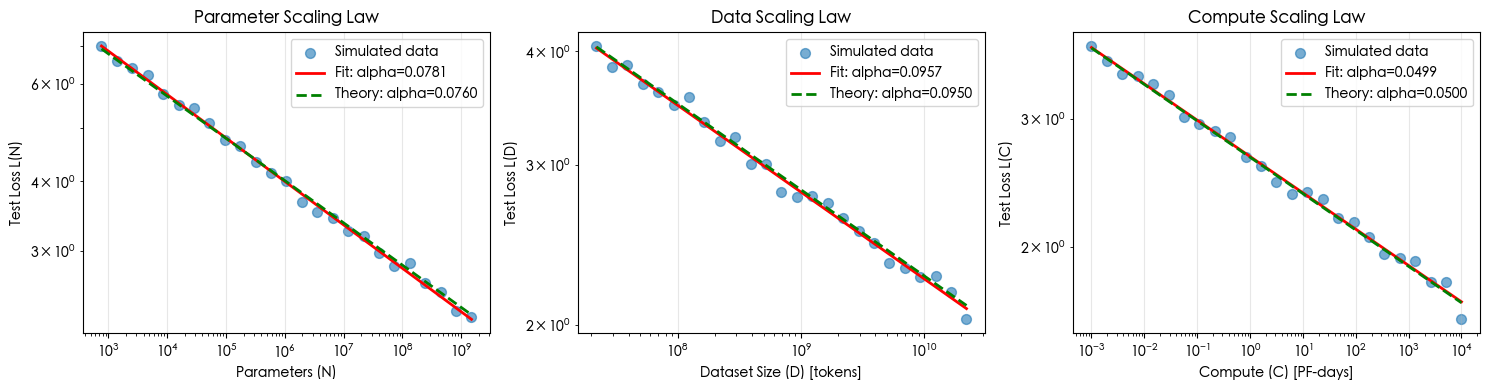

三種縮放定律圖已保存


In [4]:
def plot_scaling_law(x_data: np.ndarray, y_data: np.ndarray,
                     scaling_type: str, ax: plt.Axes) -> None:
    """
    繪製縮放定律圖
    """
    # 擬合冪律
    x_c, alpha, _ = fit_power_law(x_data, y_data)
    
    # 繪製資料點
    ax.scatter(x_data, y_data, alpha=0.6, s=50, label='Simulated data')
    
    # 繪製擬合曲線
    x_fit = np.logspace(np.log10(x_data.min()), np.log10(x_data.max()), 100)
    y_fit = power_law(x_fit, x_c, alpha)
    ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Fit: alpha={alpha:.4f}')
    
    # 繪製理論曲線
    params = SCALING_PARAMS[scaling_type]
    y_theory = power_law(x_fit, params['x_c'], params['alpha'])
    ax.plot(x_fit, y_theory, 'g--', linewidth=2, 
            label=f'Theory: alpha={params["alpha"]:.4f}')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 設定標籤
    labels = {
        'N': ('Parameters (N)', 'Test Loss L(N)'),
        'D': ('Dataset Size (D) [tokens]', 'Test Loss L(D)'),
        'C': ('Compute (C) [PF-days]', 'Test Loss L(C)')
    }
    ax.set_xlabel(labels[scaling_type][0])
    ax.set_ylabel(labels[scaling_type][1])


# 繪製三種縮放定律
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_scaling_law(N_data, L_N, 'N', axes[0])
axes[0].set_title('Parameter Scaling Law')

plot_scaling_law(D_data, L_D, 'D', axes[1])
axes[1].set_title('Data Scaling Law')

plot_scaling_law(C_data, L_C, 'C', axes[2])
axes[2].set_title('Compute Scaling Law')

plt.tight_layout()
plt.savefig('scaling_laws_three.png', dpi=150, bbox_inches='tight')
plt.show()

print('三種縮放定律圖已保存')

## 4. 簡化版 Transformer 語言模型

實作一個簡化版的 Transformer 解碼器，用於驗證縮放定律

In [5]:
class ScalingTransformer(nn.Module):
    """
    簡化版 Transformer 語言模型，用於縮放定律實驗
    """
    
    def __init__(self, 
                 vocab_size: int = 10000,
                 d_model: int = 256,
                 n_heads: int = 4,
                 n_layers: int = 4,
                 d_ff: int = 1024,
                 max_seq_len: int = 128,
                 dropout: float = 0.1):
        super().__init__()
        
        self.d_model = d_model
        self.vocab_size = vocab_size
        
        # Token 和位置嵌入
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)
        
        # Transformer 層
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 輸出層
        self.output_projection = nn.Linear(d_model, vocab_size)
        
        # 初始化權重
        self._init_weights()
        
    def _init_weights(self):
        """初始化模型權重"""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def count_parameters(self) -> int:
        """計算非嵌入參數量"""
        total = sum(p.numel() for p in self.parameters())
        embedding_params = self.token_embedding.weight.numel() + \
                          self.position_embedding.weight.numel()
        return total - embedding_params
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        前向傳播
        
        參數:
            x: 輸入序列 [batch_size, seq_len]
        
        回傳:
            logits: 輸出 logits [batch_size, seq_len, vocab_size]
        """
        batch_size, seq_len = x.shape
        
        # 嵌入
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
        x = self.token_embedding(x) + self.position_embedding(positions)
        
        # 創建因果遮罩
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        
        # Transformer 層
        x = self.transformer(x, mask=mask)
        
        # 輸出投影
        logits = self.output_projection(x)
        
        return logits


# 測試不同規模的模型
configs = [
    {'d_model': 64, 'n_heads': 2, 'n_layers': 2, 'd_ff': 256},
    {'d_model': 128, 'n_heads': 4, 'n_layers': 4, 'd_ff': 512},
    {'d_model': 256, 'n_heads': 4, 'n_layers': 6, 'd_ff': 1024},
    {'d_model': 512, 'n_heads': 8, 'n_layers': 8, 'd_ff': 2048},
]

print('不同規模模型的參數量：')
print('-' * 50)
for config in configs:
    model = ScalingTransformer(**config)
    n_params = model.count_parameters()
    print(f'd_model={config["d_model"]:4d}, n_layers={config["n_layers"]}: '
          f'{n_params:,} 非嵌入參數')

不同規模模型的參數量：
--------------------------------------------------
d_model=  64, n_layers=2: 749,968 非嵌入參數
d_model= 128, n_layers=4: 2,083,088 非嵌入參數
d_model= 256, n_layers=6: 7,308,560 非嵌入參數
d_model= 512, n_layers=8: 30,349,072 非嵌入參數


## 5. 生成合成訓練資料

In [6]:
class SyntheticLanguageDataset(torch.utils.data.Dataset):
    """
    合成語言資料集，用於縮放定律實驗
    生成具有可預測結構的序列
    """
    
    def __init__(self, 
                 n_samples: int,
                 seq_len: int,
                 vocab_size: int,
                 pattern_complexity: float = 0.5):
        """
        參數:
            n_samples: 樣本數量
            seq_len: 序列長度
            vocab_size: 詞彙表大小
            pattern_complexity: 模式複雜度 (0-1)
        """
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        self.pattern_complexity = pattern_complexity
        
        # 預先生成所有資料
        self.data = self._generate_data()
        
    def _generate_data(self) -> torch.Tensor:
        """生成合成資料"""
        data = torch.zeros(self.n_samples, self.seq_len, dtype=torch.long)
        
        for i in range(self.n_samples):
            # 混合不同的模式
            if np.random.random() < self.pattern_complexity:
                # 複雜模式：Markov 鏈
                data[i] = self._generate_markov_sequence()
            else:
                # 簡單模式：週期性序列
                data[i] = self._generate_periodic_sequence()
        
        return data
    
    def _generate_periodic_sequence(self) -> torch.Tensor:
        """生成週期性序列"""
        period = np.random.randint(2, min(10, self.seq_len // 2))
        base_pattern = torch.randint(0, self.vocab_size, (period,))
        
        sequence = base_pattern.repeat((self.seq_len // period) + 1)[:self.seq_len]
        return sequence
    
    def _generate_markov_sequence(self) -> torch.Tensor:
        """生成 Markov 序列"""
        # 建立簡單的轉移矩陣
        n_states = min(100, self.vocab_size)
        
        sequence = torch.zeros(self.seq_len, dtype=torch.long)
        sequence[0] = torch.randint(0, n_states, (1,))
        
        for t in range(1, self.seq_len):
            # 簡化的 Markov 轉移：下一個 token 依賴於當前 token
            current = sequence[t-1].item()
            # 高概率轉移到相鄰 token
            if np.random.random() < 0.7:
                sequence[t] = (current + np.random.randint(-2, 3)) % n_states
            else:
                sequence[t] = np.random.randint(0, n_states)
        
        return sequence
    
    def __len__(self) -> int:
        return self.n_samples
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        sequence = self.data[idx]
        # 輸入是序列的前 n-1 個 token，目標是後 n-1 個 token
        return sequence[:-1], sequence[1:]


# 創建資料集
train_dataset = SyntheticLanguageDataset(
    n_samples=10000,
    seq_len=65,
    vocab_size=1000,
    pattern_complexity=0.6
)

print(f'訓練資料集大小: {len(train_dataset)}')
print(f'序列長度: {train_dataset.seq_len}')
print(f'詞彙表大小: {train_dataset.vocab_size}')

訓練資料集大小: 10000
序列長度: 65
詞彙表大小: 1000


## 6. 訓練函數

In [7]:
def train_model(model: nn.Module,
                train_loader: torch.utils.data.DataLoader,
                n_epochs: int = 5,
                learning_rate: float = 1e-3) -> List[float]:
    """
    訓練模型並回傳損失歷史
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            
            logits = model(inputs)
            loss = criterion(logits.view(-1, model.vocab_size), targets.view(-1))
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
    
    return losses


def evaluate_model(model: nn.Module,
                   eval_loader: torch.utils.data.DataLoader) -> float:
    """
    評估模型，回傳平均損失
    """
    model = model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    total_loss = 0.0
    n_batches = 0
    
    with torch.no_grad():
        for inputs, targets in eval_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            logits = model(inputs)
            loss = criterion(logits.view(-1, model.vocab_size), targets.view(-1))
            
            total_loss += loss.item()
            n_batches += 1
    
    return total_loss / n_batches


print('訓練和評估函數定義完成')

訓練和評估函數定義完成


## 7. 驗證參數縮放定律

訓練不同規模的模型，驗證參數縮放定律

In [8]:
# 定義不同規模的模型配置
model_configs = [
    {'d_model': 32, 'n_heads': 2, 'n_layers': 2, 'd_ff': 128},
    {'d_model': 64, 'n_heads': 2, 'n_layers': 3, 'd_ff': 256},
    {'d_model': 96, 'n_heads': 3, 'n_layers': 4, 'd_ff': 384},
    {'d_model': 128, 'n_heads': 4, 'n_layers': 5, 'd_ff': 512},
    {'d_model': 192, 'n_heads': 4, 'n_layers': 6, 'd_ff': 768},
]

# 創建資料載入器
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=64, shuffle=True
)

# 訓練不同規模的模型
results = []
print('開始訓練不同規模的模型...')
print('-' * 60)

for i, config in enumerate(model_configs):
    print(f'\n配置 {i+1}/{len(model_configs)}: d_model={config["d_model"]}, '
          f'n_layers={config["n_layers"]}')
    
    # 創建模型
    model = ScalingTransformer(
        vocab_size=train_dataset.vocab_size,
        max_seq_len=train_dataset.seq_len,
        **config
    )
    
    n_params = model.count_parameters()
    print(f'  非嵌入參數量: {n_params:,}')
    
    # 訓練
    losses = train_model(model, train_loader, n_epochs=10, learning_rate=1e-3)
    final_loss = losses[-1]
    
    print(f'  最終損失: {final_loss:.4f}')
    
    results.append({
        'config': config,
        'n_params': n_params,
        'final_loss': final_loss,
        'loss_history': losses
    })

print('\n訓練完成！')

開始訓練不同規模的模型...
------------------------------------------------------------

配置 1/5: d_model=32, n_layers=2
  非嵌入參數量: 58,408
  最終損失: 3.6179

配置 2/5: d_model=64, n_layers=3
  非嵌入參數量: 214,952
  最終損失: 2.1320

配置 3/5: d_model=96, n_layers=4
  非嵌入參數量: 544,360


/Users/joshhu/workspace/ilya_cht/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(


  最終損失: 2.0297

配置 4/5: d_model=128, n_layers=5
  非嵌入參數量: 1,120,360
  最終損失: 1.9883

配置 5/5: d_model=192, n_layers=6
  非嵌入參數量: 2,862,184
  最終損失: 1.9350

訓練完成！


## 8. 分析並繪製實驗結果

實驗結果分析
擬合參數：x_c = 3.66e+07, alpha = 0.1868
論文參數：x_c = 8.8e13, alpha = 0.076

注意：由於使用合成資料和小規模模型，
實驗結果可能與論文有所不同


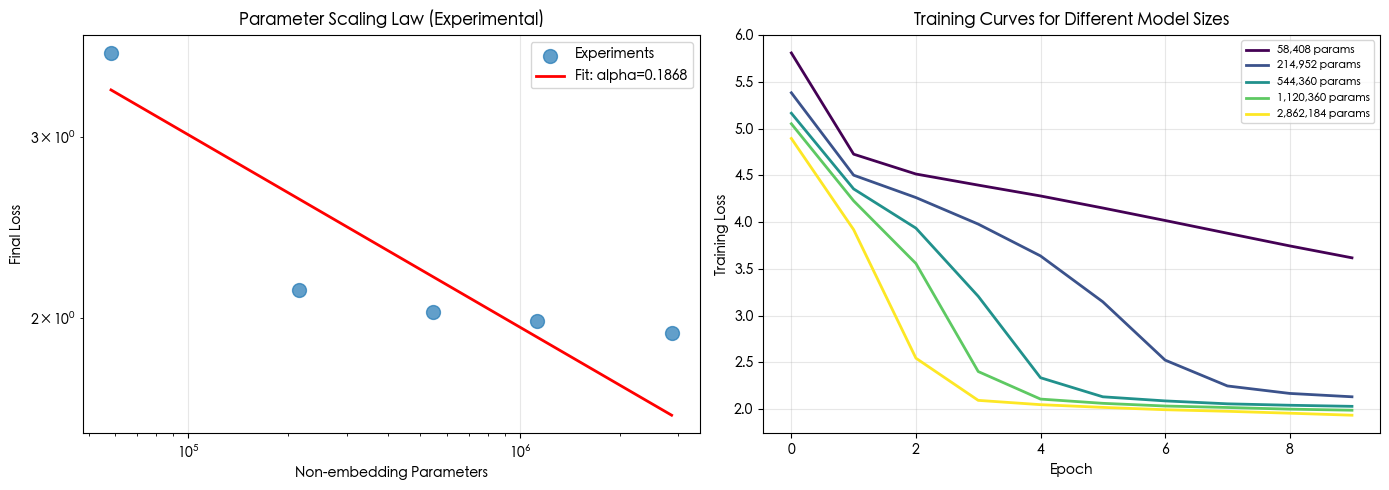


實驗圖已保存


In [9]:
# 提取資料
param_counts = np.array([r['n_params'] for r in results])
final_losses = np.array([r['final_loss'] for r in results])

# 擬合冪律
x_c, alpha, _ = fit_power_law(param_counts, final_losses)

print('實驗結果分析')
print('=' * 50)
print(f'擬合參數：x_c = {x_c:.2e}, alpha = {alpha:.4f}')
print(f'論文參數：x_c = 8.8e13, alpha = 0.076')
print(f'\n注意：由於使用合成資料和小規模模型，')
print(f'實驗結果可能與論文有所不同')

# 繪製結果
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左圖：參數縮放定律
ax = axes[0]
ax.scatter(param_counts, final_losses, s=100, alpha=0.7, label='Experiments')

# 擬合曲線
x_range = np.logspace(np.log10(param_counts.min()), 
                       np.log10(param_counts.max()), 100)
y_fit = power_law(x_range, x_c, alpha)
ax.plot(x_range, y_fit, 'r-', linewidth=2, 
        label=f'Fit: alpha={alpha:.4f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Non-embedding Parameters')
ax.set_ylabel('Final Loss')
ax.set_title('Parameter Scaling Law (Experimental)')
ax.legend()
ax.grid(True, alpha=0.3)

# 右圖：訓練曲線
ax = axes[1]
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
for i, r in enumerate(results):
    ax.plot(r['loss_history'], color=colors[i], linewidth=2,
            label=f"{r['n_params']:,} params")

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Training Curves for Different Model Sizes')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parameter_scaling_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n實驗圖已保存')

## 9. 計算最優配置

給定計算預算，計算最優的模型大小和資料量配置

In [10]:
def compute_optimal_allocation(compute_budget: float,
                                method: str = 'kaplan') -> Dict[str, float]:
    """
    計算給定計算預算下的最優配置
    
    參數:
        compute_budget: 計算預算（FLOPs）
        method: 'kaplan'（原始論文）或 'chinchilla'（Chinchilla 論文）
    
    回傳:
        包含最優 N（參數量）和 D（資料量）的字典
    """
    if method == 'kaplan':
        # 原始 Scaling Laws 論文建議
        # N_opt ∝ C^0.73, D_opt ∝ C^0.27
        # 基準：C = 10^18 FLOPs, N = 10^8, D = 10^10
        C_base = 1e18
        N_base = 1e8
        D_base = 1e10
        
        N_opt = N_base * (compute_budget / C_base) ** 0.73
        D_opt = D_base * (compute_budget / C_base) ** 0.27
        
    elif method == 'chinchilla':
        # Chinchilla 論文建議
        # N_opt ∝ C^0.5, D_opt ∝ C^0.5
        # 約 20 tokens per parameter
        C_base = 1e18
        N_base = 4e7  # 較小的基準
        D_base = 8e8  # 較大的基準
        
        N_opt = N_base * (compute_budget / C_base) ** 0.5
        D_opt = D_base * (compute_budget / C_base) ** 0.5
    
    # 驗證 C ≈ 6ND
    computed_C = 6 * N_opt * D_opt
    
    return {
        'N_opt': N_opt,
        'D_opt': D_opt,
        'tokens_per_param': D_opt / N_opt,
        'computed_C': computed_C,
        'budget_utilization': computed_C / compute_budget
    }


# 比較不同計算預算下的最優配置
compute_budgets = [1e17, 1e18, 1e19, 1e20, 1e21, 1e22]

print('計算最優配置比較')
print('=' * 80)
print(f'{"Compute (FLOPs)":>15} | {"Method":>10} | {"N_opt":>12} | '
      f'{"D_opt":>12} | {"Tokens/Param":>12}')
print('-' * 80)

for C in compute_budgets:
    for method in ['kaplan', 'chinchilla']:
        result = compute_optimal_allocation(C, method)
        print(f'{C:>15.0e} | {method:>10} | {result["N_opt"]:>12.2e} | '
              f'{result["D_opt"]:>12.2e} | {result["tokens_per_param"]:>12.1f}')

計算最優配置比較
Compute (FLOPs) |     Method |        N_opt |        D_opt | Tokens/Param
--------------------------------------------------------------------------------
          1e+17 |     kaplan |     1.86e+07 |     5.37e+09 |        288.4
          1e+17 | chinchilla |     1.26e+07 |     2.53e+08 |         20.0
          1e+18 |     kaplan |     1.00e+08 |     1.00e+10 |        100.0
          1e+18 | chinchilla |     4.00e+07 |     8.00e+08 |         20.0
          1e+19 |     kaplan |     5.37e+08 |     1.86e+10 |         34.7
          1e+19 | chinchilla |     1.26e+08 |     2.53e+09 |         20.0
          1e+20 |     kaplan |     2.88e+09 |     3.47e+10 |         12.0
          1e+20 | chinchilla |     4.00e+08 |     8.00e+09 |         20.0
          1e+21 |     kaplan |     1.55e+10 |     6.46e+10 |          4.2
          1e+21 | chinchilla |     1.26e+09 |     2.53e+10 |         20.0
          1e+22 |     kaplan |     8.32e+10 |     1.20e+11 |          1.4
          1e+22 | chin

## 10. 視覺化計算最優配置

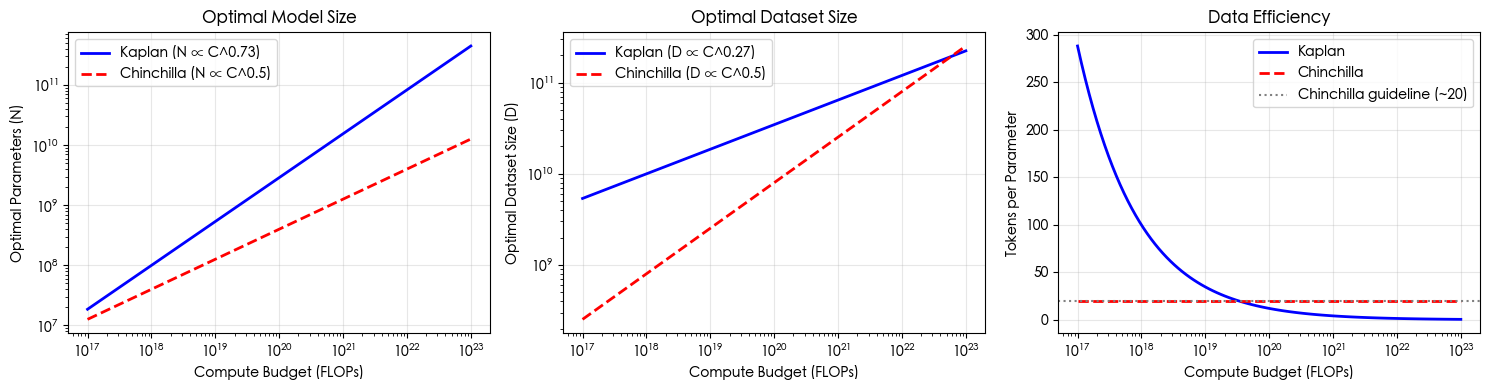

計算最優配置圖已保存


In [11]:
# 繪製兩種方法的比較
compute_range = np.logspace(17, 23, 100)

kaplan_N = [compute_optimal_allocation(C, 'kaplan')['N_opt'] for C in compute_range]
kaplan_D = [compute_optimal_allocation(C, 'kaplan')['D_opt'] for C in compute_range]
chinchilla_N = [compute_optimal_allocation(C, 'chinchilla')['N_opt'] for C in compute_range]
chinchilla_D = [compute_optimal_allocation(C, 'chinchilla')['D_opt'] for C in compute_range]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 參數量 vs 計算量
ax = axes[0]
ax.loglog(compute_range, kaplan_N, 'b-', linewidth=2, label='Kaplan (N ∝ C^0.73)')
ax.loglog(compute_range, chinchilla_N, 'r--', linewidth=2, label='Chinchilla (N ∝ C^0.5)')
ax.set_xlabel('Compute Budget (FLOPs)')
ax.set_ylabel('Optimal Parameters (N)')
ax.set_title('Optimal Model Size')
ax.legend()
ax.grid(True, alpha=0.3)

# 資料量 vs 計算量
ax = axes[1]
ax.loglog(compute_range, kaplan_D, 'b-', linewidth=2, label='Kaplan (D ∝ C^0.27)')
ax.loglog(compute_range, chinchilla_D, 'r--', linewidth=2, label='Chinchilla (D ∝ C^0.5)')
ax.set_xlabel('Compute Budget (FLOPs)')
ax.set_ylabel('Optimal Dataset Size (D)')
ax.set_title('Optimal Dataset Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Tokens per parameter
ax = axes[2]
kaplan_ratio = [compute_optimal_allocation(C, 'kaplan')['tokens_per_param'] 
                for C in compute_range]
chinchilla_ratio = [compute_optimal_allocation(C, 'chinchilla')['tokens_per_param'] 
                    for C in compute_range]
ax.semilogx(compute_range, kaplan_ratio, 'b-', linewidth=2, label='Kaplan')
ax.semilogx(compute_range, chinchilla_ratio, 'r--', linewidth=2, label='Chinchilla')
ax.axhline(y=20, color='gray', linestyle=':', label='Chinchilla guideline (~20)')
ax.set_xlabel('Compute Budget (FLOPs)')
ax.set_ylabel('Tokens per Parameter')
ax.set_title('Data Efficiency')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('compute_optimal_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

print('計算最優配置圖已保存')

## 11. 預測模型性能

使用縮放定律預測不同配置的模型性能

In [12]:
def predict_loss(N: float, D: float,
                 N_c: float = 8.8e13,
                 D_c: float = 5.4e13,
                 alpha_N: float = 0.076,
                 alpha_D: float = 0.095) -> float:
    """
    使用聯合縮放公式預測損失
    
    L(N, D) = [(N_c/N)^(alpha_N/alpha_D) + D_c/D]^alpha_D
    """
    term1 = (N_c / N) ** (alpha_N / alpha_D)
    term2 = D_c / D
    return (term1 + term2) ** alpha_D


# 預測一些知名模型的性能
models = [
    {'name': 'GPT-2 Small', 'N': 117e6, 'D': 40e9},
    {'name': 'GPT-2 Medium', 'N': 345e6, 'D': 40e9},
    {'name': 'GPT-2 Large', 'N': 762e6, 'D': 40e9},
    {'name': 'GPT-2 XL', 'N': 1.5e9, 'D': 40e9},
    {'name': 'GPT-3 175B', 'N': 175e9, 'D': 300e9},
    {'name': 'LLaMA 7B', 'N': 7e9, 'D': 1.4e12},
    {'name': 'LLaMA 70B', 'N': 70e9, 'D': 1.4e12},
]

print('使用縮放定律預測模型性能')
print('=' * 70)
print(f'{"Model":>20} | {"Parameters":>12} | {"Tokens":>12} | {"Predicted Loss":>14}')
print('-' * 70)

for model in models:
    loss = predict_loss(model['N'], model['D'])
    print(f'{model["name"]:>20} | {model["N"]:>12.2e} | {model["D"]:>12.2e} | {loss:>14.4f}')

print('\n注意：預測值僅供參考，實際性能受多種因素影響')

使用縮放定律預測模型性能
               Model |   Parameters |       Tokens | Predicted Loss
----------------------------------------------------------------------
         GPT-2 Small |     1.17e+08 |     4.00e+10 |         2.8034
        GPT-2 Medium |     3.45e+08 |     4.00e+10 |         2.5910
         GPT-2 Large |     7.62e+08 |     4.00e+10 |         2.4515
            GPT-2 XL |     1.50e+09 |     4.00e+10 |         2.3451
          GPT-3 175B |     1.75e+11 |     3.00e+11 |         1.7323
            LLaMA 7B |     7.00e+09 |     1.40e+12 |         2.0530
           LLaMA 70B |     7.00e+10 |     1.40e+12 |         1.7399

注意：預測值僅供參考，實際性能受多種因素影響


## 12. 繪製聯合縮放曲面

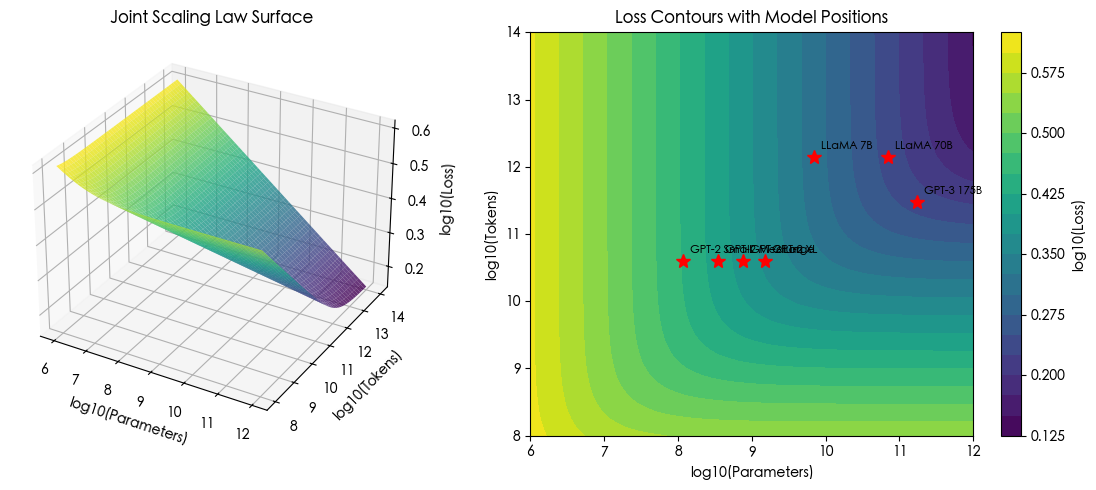

聯合縮放曲面圖已保存


In [13]:
from mpl_toolkits.mplot3d import Axes3D

# 創建參數和資料量的網格
N_range = np.logspace(6, 12, 50)  # 1M to 1T parameters
D_range = np.logspace(8, 14, 50)  # 100M to 100T tokens
N_grid, D_grid = np.meshgrid(N_range, D_range)

# 計算損失曲面
Loss_grid = np.zeros_like(N_grid)
for i in range(N_grid.shape[0]):
    for j in range(N_grid.shape[1]):
        Loss_grid[i, j] = predict_loss(N_grid[i, j], D_grid[i, j])

# 繪製 3D 曲面
fig = plt.figure(figsize=(12, 5))

# 3D 曲面圖
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(np.log10(N_grid), np.log10(D_grid), np.log10(Loss_grid),
                        cmap='viridis', alpha=0.8)
ax1.set_xlabel('log10(Parameters)')
ax1.set_ylabel('log10(Tokens)')
ax1.set_zlabel('log10(Loss)')
ax1.set_title('Joint Scaling Law Surface')

# 等高線圖
ax2 = fig.add_subplot(122)
contour = ax2.contourf(np.log10(N_grid), np.log10(D_grid), np.log10(Loss_grid),
                       levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='log10(Loss)')

# 標註一些知名模型
for model in models:
    ax2.plot(np.log10(model['N']), np.log10(model['D']), 'r*', markersize=10)
    ax2.annotate(model['name'], (np.log10(model['N']), np.log10(model['D'])),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('log10(Parameters)')
ax2.set_ylabel('log10(Tokens)')
ax2.set_title('Loss Contours with Model Positions')

plt.tight_layout()
plt.savefig('joint_scaling_surface.png', dpi=150, bbox_inches='tight')
plt.show()

print('聯合縮放曲面圖已保存')

## 13. 總結與關鍵發現

本 notebook 實作並驗證了神經語言模型的縮放定律：

### 核心公式回顧

1. **參數縮放**：$L(N) = (N_c/N)^{\alpha_N}$，$\alpha_N \approx 0.076$

2. **資料縮放**：$L(D) = (D_c/D)^{\alpha_D}$，$\alpha_D \approx 0.095$

3. **計算縮放**：$L(C) = (C_c/C)^{\alpha_C}$，$\alpha_C \approx 0.050$

4. **計算量估算**：$C \approx 6ND$

### 計算最優配置

- **Kaplan et al. (2020)**：$N_{opt} \propto C^{0.73}$，$D_{opt} \propto C^{0.27}$
- **Chinchilla (2022)**：$N_{opt} \propto C^{0.5}$，$D_{opt} \propto C^{0.5}$（約 20 tokens per parameter）

### 實際應用

縮放定律允許我們：
- 預測更大模型的性能
- 優化計算資源分配
- 指導模型架構設計決策

In [14]:
print('=' * 60)
print('Scaling Laws for Neural Language Models')
print('神經語言模型的縮放定律')
print('=' * 60)
print()
print('本 notebook 涵蓋：')
print('1. 冪律函數的定義與擬合方法')
print('2. 三種核心縮放定律（參數、資料、計算）的視覺化')
print('3. 簡化版 Transformer 模型的實作')
print('4. 實驗驗證參數縮放定律')
print('5. 計算最優配置的計算與比較')
print('6. 聯合縮放曲面的視覺化')
print('7. 模型性能預測')
print()
print('參考文獻：')
print('Kaplan et al., "Scaling Laws for Neural Language Models"')
print('arXiv:2001.08361, 2020')

Scaling Laws for Neural Language Models
神經語言模型的縮放定律

本 notebook 涵蓋：
1. 冪律函數的定義與擬合方法
2. 三種核心縮放定律（參數、資料、計算）的視覺化
3. 簡化版 Transformer 模型的實作
4. 實驗驗證參數縮放定律
5. 計算最優配置的計算與比較
6. 聯合縮放曲面的視覺化
7. 模型性能預測

參考文獻：
Kaplan et al., "Scaling Laws for Neural Language Models"
arXiv:2001.08361, 2020
